In [ ]:
# If running inside Jupyter / Colab
!pip install -q \
    pandas \
    setfit \
    ollama \
    rouge-score \
    requests \
    sentence-transformers \
    umap-learn \
    matplotlib \
    datasets

In [2]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
from datasets import load_dataset
from StanceDetector import StanceDetector
import utils
import random

random_seed=42


In [3]:
records = {
    "nuclear":{
        'keywords':[
            "Power plant",
            "Nuclear power generation",
            "Decommissioning",
            "Nuclear fuel",
            "Radioactivity",
            "Radioactive waste",
            "Energy base load power source",
            "Fukushima",
            "Chernobyl",
            "Daiichi Nuclear Power Plant",
            # General nuclear-energy vocabulary
            "Nuclear reactors",
            "Pressurised Water Reactor",
            "Advanced Gas-cooled Reactor",
            "Small Modular Reactors",
            "Advanced Modular Reactors",
            "Nuclear fission",
            "Nuclear fusion",
            "Uranium enrichment",
            "Fuel reprocessing",
            "Spent fuel management",
            "Nuclear contamination",
            "Nuclear decontamination",
            "Radiation leakage",
            # UK-specific nuclear infrastructure
            "Hinkley Point C",
            "Sizewell C",
            "Wylfa Newydd",
            "Oldbury",
            "Bradwell B",
            "Sellafield",
            "Dounreay",
            "Magnox reactors",
            "Office for Nuclear Regulation",
            "Nuclear Decommissioning Authority",
            "Energy Security Strategy",
            "Regulated Asset Base model",
            "RAB model",
            # Political and policy themes
            "Nuclear financing",
            # Risk and crisis terms
            "Nuclear meltdown",
            "Core containment",
            "Emergency cooling system",
            # Geopolitical and supply chain
            "Uranium supply chain",
            "Nuclear cooperation agreements",
            "Russian uranium",
            ],
        'policyarea':[7, 8],
        
        },

    "climate change": {
        'keywords':
            [
        # --- General & Scientific ---
        "climate change", "global warming", "anthropogenic", "climate emergency",
        "greenhouse gas", "greenhouse gases", "greenhouse-gas",
        "carbon emissions", "carbon emission", "CO2 emissions", "carbon dioxide",
        "carbon footprint", "carbon footprints", "carbon-footprint",
        "climate science", "climate-science", "climatology", "climatologist",
        "climate skeptic", "climate skeptics", "climate sceptic", "climate sceptics",
        "climate denial", "climate denier", "climate deniers", "climate-denial",

        # --- UK Legislation & Policy (2010-2014 Focus) ---
        "Climate Change Act", "Energy Act 2011", "Energy Act 2013",
        "Carbon Budget", "Carbon Budgets", "Fourth Carbon Budget",
        "Green Deal", "Green-Deal", "Energy Company Obligation", "ECO scheme",
        "Electricity Market Reform", "EMR", "Contracts for Difference", "CfD", "CfDs",
        "Capacity Market", "Emissions Performance Standard", "EPS",
        "Renewables Obligation", "ROCs", "Feed-in Tariff", "Feed-in Tariffs", "FiTs",
        "Carbon Floor Price", "Carbon Price Floor", "CPF", "Carbon Price Support",
        "Green Investment Bank", "GIB", "DECC", "Department of Energy and Climate Change",

        # --- Energy Sector & Technology ---
        "renewable energy", "renewables", "clean energy", "green energy",
        "onshore wind", "offshore wind", "wind farm", "wind farms", "wind turbine",
        "solar power", "solar panels", "photovoltaic", "solar PV",
        "nuclear power", "nuclear energy", "new nuclear", "Hinkley Point C", "Hinkley Point",
        "shale gas", "fracking", "hydraulic fracturing", "shale-gas",
        "carbon capture and storage", "CCS", "carbon-capture",
        "biomass", "coal-to-biomass", "Drax", "energy security", "energy-security",
        "interconnector", "interconnectors", "smart meter", "smart meters", "smart-metering",

        # --- Political Rhetoric & Economic Positioning ---
        "greenest government ever", "green crap", "green tape", "green-tape",
        "green growth", "green economy", "green jobs", "low carbon economy", "low-carbon",
        "fuel poverty", "energy bills", "energy prices", "energy price freeze", 
        "cost of living", "stealth tax", "green levies", "green levy",
        "decarbonisation", "decarbonization", "decarbonise", "decarbonize",
        "sustainability", "sustainable development", "mitigation", "adaptation",

        # --- International Context (Relevant to 2010-2014) ---
        "Copenhagen Accord", "Cancun Agreement", "Durban Platform", "Doha Climate Gateway",
        "IPCC", "Intergovernmental Panel on Climate Change", "Fifth Assessment Report", "AR5",
        "Kyoto Protocol", "United Nations Framework Convention on Climate Change", "UNFCCC",
        "COP16", "COP17", "COP18", "COP19", "COP20", "EU Emissions Trading System", "EU ETS"
    ],
        'policyarea':[8],
        
        },
    "Gaza":{ 
        'keywords': [
            # Israeli political figures
            "Netanyahu",
            "Benjamin Netanyahu",
            "Ehud Olmert",
            "Ariel Sharon",
            "Ehud Barak",
            "Tzipi Livni",
            "Naftali Bennett",
            "Yair Lapid",
            "Avigdor Lieberman",
            "Shimon Peres",
            "Isaac Herzog",
            "Reuven Rivlin",
            "Benny Gantz",
            "Yoav Gallant",
            "Ben Gvir",
            "Zionism", "Zionist", "anti-zionist", "anti-zionism",

            # Palestinian political figures
            "Mahmoud Abbas",
            "Abu Mazen",
            "Ismail Haniyeh",
            "Yahya Sinwar",
            "Marwan Barghouti",
            "Saeb Erekat",
            "Mohammad Shtayyeh",
            "Khaled Mashal",
            "Ahmed Yassin",
            "Mohammed Deif",

            # Israeli institutions / organisations
            "Knesset",

            "Israel Defense Forces",
            "Shin Bet",
            "Mossad",
            "Likud",
            "Yesh Atid",
            "Blue and White",
            "Kadima",
            "Religious Zionism party",
            "Shas",
            "Meretz",

            # Palestinian institutions / organisations
            "Palestine Liberation Organization",
            "Fatah",
            "Hamas",
            "Popular Front for the Liberation of Palestine",
            "PFLP",
            "Al-Qassam Brigades",
            "Palestinian Legislative Council",

            # Key places (Gaza / Israel)
            "Gaza City",
            "Rafah",
            "Khan Younis",
            "Jabalia",
            "Beit Hanoun",
            "Deir al-Balah",
            "Shuja'iyya",
            "Nuseirat",
            "Beit Lahia",
            "Al-Shifa Hospital",

            # Key places (Israel)
            "Sderot",
            "Ashkelon",
            "Ashdod",
            "Beersheba",
            "Tel Aviv",
            "Jerusalem",
            "West Jerusalem",
            "East Jerusalem",
            "Haifa",
            "Eilat",

            # Crossings and checkpoints
            "Erez Crossing",
            "Kerem Shalom Crossing",
            "Rafah Crossing",
            "Qalandia",
            "Allenby Bridge Crossing",
            "Gilo checkpoint",

            # Named military operations (appear frequently in UK Parliament debates)
            "Operation Cast Lead",
            "Operation Pillar of Defense",
            "Operation Protective Edge",
            "Operation Guardian of the Walls",
            "Operation Breaking Dawn",
            "Operation Iron Swords",
            "Operation Summer Rains",
            "Operation Autumn Clouds",

            # International actors mentioned regarding the conflict
            "UNRWA",
            "UN Human Rights Council",
            "Quartet on the Middle East",
            

            # Other region-specific named entities
            "Al-Aqsa Mosque",
            "Temple Mount",
            "Haram al-Sharif",
            "Sheikh Jarrah",
            "Hebron",
            "Nablus",
            "Ramallah",
            "Bethlehem",
            "Jenin",

            # NGOs / rights groups mentioned often
            "B'Tselem",
            "Breaking the Silence",
            "ICRC"
        ],
        'policyarea':[16, 18, 19],
        
    }}

In [4]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

In [3]:
# read records from json file
with open('./../data/external/records.json', 'r') as f:
    records = json.load(f) 


In [4]:
def politician_stance(summarizations, name):
    summary = summarizations[summarizations['speaker'] == name]['summary']
    if not summary.empty:
        return summary.iloc[0]
    else:
        return f"No summary found for {name}."

In [34]:
import importlib
import StanceDetector as sd_module

def reload_detector():
    importlib.reload(sd_module)
    return sd_module.StanceDetector

In [5]:
# results_df=pd.DataFrame(columns=[
#     'anchor',
#     'topic', 
#     'predicted_ordering', 
#     'gold_ordering',
#     'summarization_model', 
#     'embedding_model',
#     'external_model',
#     'kendall_tau', 
#     'spearman_rho',
#     'kendall_p',
#     'spearman_p',
#     'lcs_ratio',])

results_df=pd.read_csv('./../data/processed/evaluation_results.csv')

In [6]:
def add_result(df, anchor, topic, predicted_ordering, gold_ordering, summarization_model, embedding_model, external_model, kendall_tau, spearman_rho, kendall_p,spearman_p, lcs_ratio ):
    new_row = {
        'anchor': anchor,
        'topic': topic,
        'predicted_ordering': predicted_ordering,
        'gold_ordering': gold_ordering,
        'summarization_model': summarization_model,
        'embedding_model': embedding_model,
        'external_model': external_model,
        'kendall_tau': kendall_tau,
        'spearman_rho': spearman_rho,
        'kendall_p': kendall_p,
        'spearman_p': spearman_p,
        'lcs_ratio': lcs_ratio,
    }
    df.loc[len(df)] = new_row
    return df

In [13]:
summarization_models=[ 'deepseek-r1:8b', 'gemma3']

## Gaza

In [4]:
topic='Gaza'
years = [2011, 2012, 2013, 2014]

In [37]:
summarization_model='qwen3:8b'
embedding_model="Qwen/Qwen3-Embedding-0.6B"

In [18]:
uk=StanceDetector(df1, records, random_seed=random_seed)

In [12]:
filtered_df= uk.filter_speeches(topic, years=years) 
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic, model_name=summarization_model)


Filtering speeches for topic: Gaza
Number of speeches after filtering for topic 'Gaza' in years [2011, 2012, 2013, 2014]: 1547
Classifying filtered speeches for topic: Gaza
"Number of opinionated speeches for Gaza: 238
Summarization completed for topic: Gaza


In [11]:
# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}_{summarization_model}.csv', index=False)

In [38]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}_{summarization_model}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)

In [39]:
anchors=uk.generate_anchors(topic, model_name=summarization_model)
anchors

Generating stance anchors for topic: Gaza


[{'topic': 'Should Hamas be recognized as a legitimate political entity in any peace process?',
  'pro': "Hamas's commitment to Israel's destruction and refusal to renounce violence disqualify it from participating in negotiations.",
  'con': "Hamas's political legitimacy should be assessed based on its actions, not preconditions, to enable meaningful dialogue."},
 {'topic': "Is a two-state solution viable without addressing Hamas's influence in Gaza?",
  'pro': "Hamas's control over Gaza undermines Palestinian statehood and must be resolved before peace talks.",
  'con': "A two-state solution requires addressing Israeli settlements and occupation, not solely Hamas's actions."},
 {'topic': 'Should international actors prioritize humanitarian aid over security concerns in Gaza?',
  'pro': 'Blockades and restrictions exacerbate the humanitarian crisis and fuel radicalization.',
  'con': 'Security measures are necessary to prevent Hamas from exploiting aid for military purposes.'},
 {'top

In [40]:
# saving anchors to json file
with open(f'./../data/processed/anchors_{topic}_{summarization_model}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [12]:
# DEBUG: loading anchors from json file
with open(f'./../data/processed/anchors_{topic}_{summarization_model}.json', 'r') as f:
    anchors = json.load(f)

In [ ]:
anchor_number=0
chosen_anchor = anchors[anchor_number]
chosen_anchor

{'topic': 'Should Hamas be recognized as a legitimate political entity in any peace process?',
 'pro': "Hamas's commitment to Israel's destruction and refusal to renounce violence disqualify it from participating in negotiations.",
 'con': "Hamas's political legitimacy should be assessed based on its actions, not preconditions, to enable meaningful dialogue."}

Computing UMAP embeddings for topic: Gaza


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


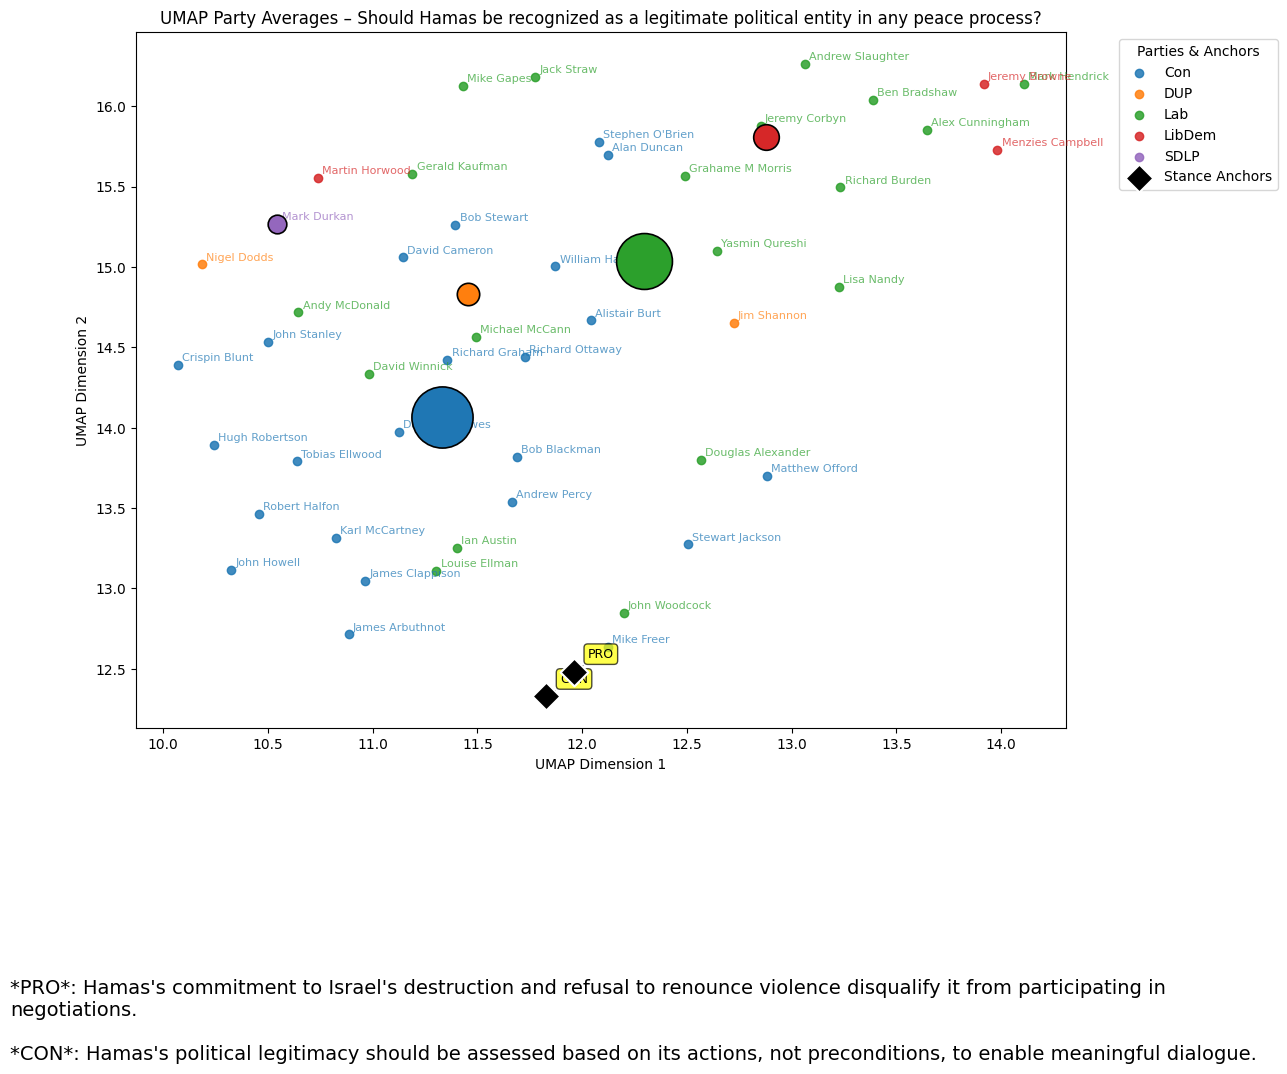

In [ ]:
speaker_embeddings, anchor_embeddings, top_politicians = uk.compute_embeddings(topic, chosen_anchor, model_name=embedding_model)
umap_data = uk.compute_umap_embeddings(
    topic,
    chosen_anchor,
    speaker_embeddings=speaker_embeddings,
    anchor_embeddings=anchor_embeddings,
 )
save_path=f'./../data/processed/{topic}_{summarization_model}_{anchor_number}_'
uk.plot_umap_party_averages(umap_data, save_path=save_path)

In [ ]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)

print("Speaker embeddings shape:", speaker_embeddings.shape)
print("Anchor embeddings shape:", anchor_embeddings.shape)
print("Top politicians considered:", top_politicians)

Computing embeddings for topic: Gaza
["The politician views Hamas as a terrorist entity responsible for the humanitarian crisis in Gaza, calls for its removal from power, and supports actions to stop Hamas's funding and weapon supply. They emphasize the need to address Hamas's misuse of aid for military purposes and reject Palestinian state recognition while Hamas remains in control.", "The politician argues that groups like Hamas and Hezbollah seek Israel's destruction and questions whether recognizing a Palestinian state would stop their support for Israel's annihilation.", "The politician believes Hamas must accept the Quartet principles—recognizing Israel, upholding past agreements, and renouncing violence—for any peace process to succeed, as Hamas's refusal is a key barrier to lasting peace in the region.", "The politician criticizes Israel's expansion of settlements and construction of a barrier that separates East Jerusalem from the West Bank, making it harder for East Jerusalem

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Speaker embeddings shape: (10, 1024)
Anchor embeddings shape: (2, 1024)
Top politicians considered: ['Robert Halfon', 'Nigel Dodds', 'Mike Freer', 'Jeremy Browne', 'Douglas Alexander', 'Michael McCann', 'Mike Gapes', 'Bob Stewart', 'Mark Hendrick', 'John Stanley']


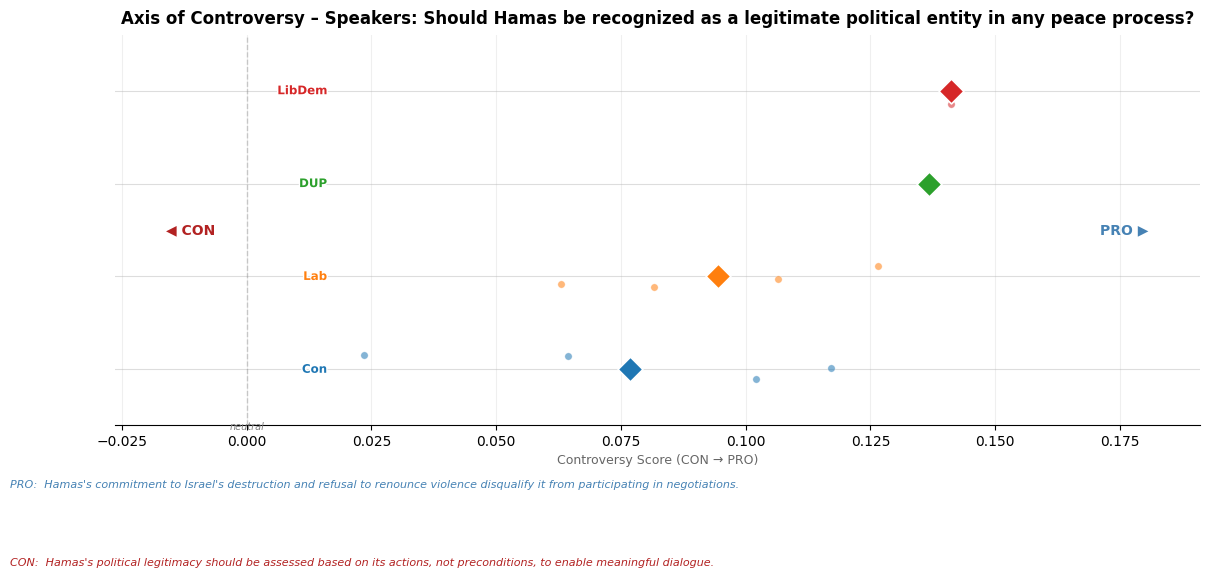

In [44]:
issue = chosen_anchor['topic']
speaker_df = uk.axis_of_controversy(topic, issue=issue, speaker_embeddings=speaker_embeddings, anchor_embeddings=anchor_embeddings)
speaker_df = speaker_df.sort_values(by='controversy_score', ascending=True)
# plot axis of controversy with speakers projected onto it
uk.plot_axis_of_controversy(speaker_df, anchors=chosen_anchor)

In [45]:
party_order = (
            speaker_df.groupby('party')['controversy_score']
            .mean()
            .sort_values()
            .index.tolist()
        )
party_order

['Con', 'Lab', 'DUP', 'LibDem']

In [46]:
#------ INSERT HERE THE ORDERINGS GIVEN BY THE EXTERNAL LLM -----------
ext_model='GPT-5.4 Thinking'
gold_ordering = ['SDLP', 'LibDem', 'Lab', 'Con', 'DUP']

In [47]:
# evaluation of the ordering of parties along the controversy axis
#get unique party labels in the speaker_df

party_order = (
            speaker_df.groupby('party')['controversy_score']
            .mean()
            .sort_values()
            .index.tolist()
        )

print("Predicted ordering:", party_order)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=party_order, gold_ordering=gold_ordering)
print(metrics)

Predicted ordering: ['Con', 'Lab', 'DUP', 'LibDem']
Gold standard ordering: ['SDLP', 'LibDem', 'Lab', 'Con', 'DUP']
{'spearman_rho': np.float64(-0.4), 'spearman_p': np.float64(0.6), 'kendall_tau': np.float64(-0.3333), 'kendall_p': np.float64(0.75), 'lcs_ratio': 0.5, 'n_parties': 4}


In [ ]:
add_result(
    df=results_df,
    anchor=chosen_anchor,
    topic=topic,
    predicted_ordering=party_order,
    gold_ordering=gold_ordering,
    summarization_model=summarization_model,
    embedding_model=embedding_model,
    external_model=ext_model,
    kendall_tau=metrics['kendall_tau'],
    spearman_rho=metrics['spearman_rho'],
    kendall_p=metrics['kendall_p'],
    spearman_p=metrics['spearman_p'],
    lcs_ratio=metrics['lcs_ratio']
)
results_df.tail(1)

,anchor,topic,predicted_ordering,gold_ordering,summarization_model,embedding_model,external_model,kendall_tau,spearman_rho
6,{'topic': 'Should Hamas be recognized as a leg...,Gaza,"[Con, Lab, DUP, LibDem]","[SDLP, LibDem, Lab, Con, DUP]",qwen3:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,-0.3333,-0.4


In [49]:
results_df.to_csv('./../data/processed/evaluation_results.csv', index=False)

## Results

In [4]:
results_df

,anchor,topic,predicted_ordering,gold_ordering,summarization_model,embedding_model,external_model,kendall_tau,spearman_rho,kendall_p,lcs_ratio,spearman_p
0,"{'topic': ""Hamas's culpability for the conflic...",Gaza,"['DUP', 'Lab', 'Con', 'LibDem']","['Lab', 'LibDem', 'SDLP', 'Con', 'DUP']",deepseek-r1:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,0.6667,0.8,0.0000,0.5789,0.0000
1,"{'topic': 'The Legitimacy of Hamas', 'pro': 'H...",Gaza,"['DUP', 'LibDem', 'Con', 'Lab']","['Con', 'Lab', 'LibDem', 'SDLP']",gemma3,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,-0.3333,-0.5,0.0001,0.6129,0.0002
2,"{'topic': ""Hamas's culpability for the conflic...",Gaza,"['LibDem', 'Lab', 'Con', 'DUP']","['Lab', 'LibDem', 'SDLP', 'Con', 'DUP']",deepseek-r1:8b,Qwen/Qwen3-Embedding-4B,GPT-5.4 Thinking,0.6667,0.8,0.0000,0.7632,0.0000
3,{'topic': 'Should Israel’s military operations...,Gaza,"['Con', 'DUP', 'Lab', 'LibDem']","['Lab', 'LibDem', 'SDLP', 'Con']",ministral-3:8b,Qwen/Qwen3-Embedding-4B,GPT-5.4 Thinking,-0.3333,-0.5,1.0000,0.6667,0.6667
4,{'topic': 'Should Israel’s military operations...,Gaza,"['Con', 'DUP', 'Lab', 'LibDem']","['Lab', 'LibDem', 'SDLP', 'Con']",ministral-3:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,-0.3333,-0.5,1.0000,0.6667,0.6667
5,{'topic': 'Should Israel’s military operations...,Gaza,"['Con', 'DUP', 'Lab', 'LibDem']","['Lab', 'LibDem', 'SDLP', 'Con']",ministral-3:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,-0.3333,-0.5,1.0000,0.6667,0.6667
6,{'topic': 'Should Hamas be recognized as a leg...,Gaza,"['Con', 'Lab', 'DUP', 'LibDem']","['SDLP', 'LibDem', 'Lab', 'Con', 'DUP']",qwen3:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,-0.3333,-0.4,0.7500,0.5000,0.6000


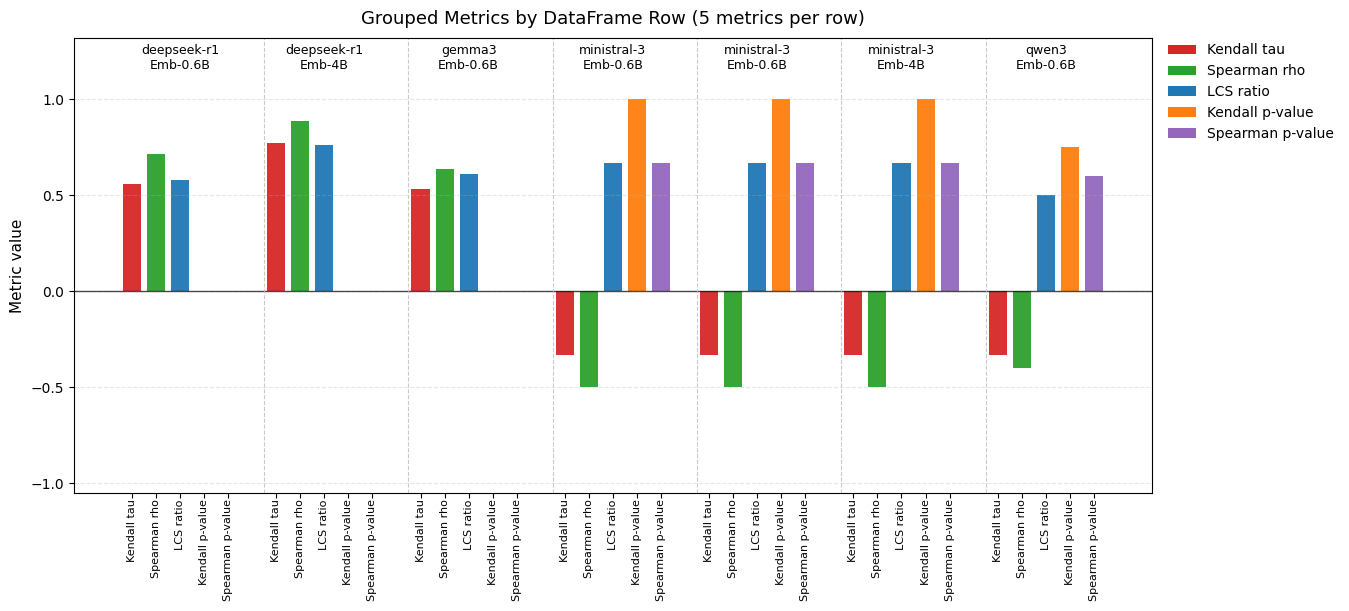

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 5 metriche per ogni riga (gruppi lungo asse x)
metric_order = ["kendall_tau", "spearman_rho", "lcs_ratio", "kendall_p", "spearman_p"]
metric_titles = {
    "kendall_tau": "Kendall tau",
    "spearman_rho": "Spearman rho",
    "lcs_ratio": "LCS ratio",
    "kendall_p": "Kendall p-value",
    "spearman_p": "Spearman p-value",
}
metric_colors = {
    "kendall_tau": "#d62728",   # rosso
    "spearman_rho": "#2ca02c",  # verde
    "lcs_ratio": "#1f77b4",     # blu
    "kendall_p": "#ff7f0e",     # arancio
    "spearman_p": "#9467bd",    # viola
}

required_cols = ["summarization_model", "embedding_model", "topic", *metric_order]
missing_cols = [c for c in required_cols if c not in results_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in results_df: {missing_cols}")

plot_df = results_df[required_cols].copy()
plot_df = plot_df.sort_values(["topic", "summarization_model", "embedding_model"]).reset_index(drop=True)

# Label gruppo: summarization + embedding
plot_df["summ_label"] = plot_df["summarization_model"].str.replace(":8b", "", regex=False)
plot_df["emb_label"] = (
    plot_df["embedding_model"]
    .str.replace("Qwen/", "", regex=False)
    .str.replace("Qwen3-Embedding-", "Emb-", regex=False)
)
plot_df["group_label"] = plot_df["summ_label"] + "\n" + plot_df["emb_label"]

n_rows = len(plot_df)
n_metrics = len(metric_order)
group_gap = 1.0  # spazio aggiuntivo tra righe/gruppi
bar_width = 0.75

x_positions = []
x_labels = []

fig_w = max(14, n_rows * 2.0)
fig, ax = plt.subplots(figsize=(fig_w, 7))

for i, row in plot_df.iterrows():
    base = i * (n_metrics + group_gap)
    center_x = base + (n_metrics - 1) / 2

    for j, metric in enumerate(metric_order):
        x = base + j
        val = row[metric]
        if np.isnan(val):
            continue

        ax.bar(
            x,
            val,
            width=bar_width,
            color=metric_colors[metric],
            alpha=0.95,
        )

        x_positions.append(x)
        x_labels.append(metric_titles[metric])

    # Etichetta modello sopra il gruppo di 5 metriche
    ax.text(
        center_x,
        1.14,
        row["group_label"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Asse y: da +1 in alto a -1 in basso
ax.set_ylim(-1.05, 1.32)
ax.set_yticks([1, 0.5, 0, -0.5, -1])
ax.set_ylabel("Metric value", fontsize=11)

# Riferimenti visivi
ax.axhline(0, color="black", linewidth=1.0, alpha=0.7)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Ticks x ripetuti per metrica (5 per gruppo)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
ax.tick_params(axis="x", pad=1)

# Separatore tra gruppi (righe del dataframe)
for i in range(n_rows - 1):
    sep_x = (i + 1) * (n_metrics + group_gap) - (group_gap / 2)
    ax.axvline(sep_x, color="#bdbdbd", linewidth=0.8, linestyle="--", alpha=0.8)

# Legenda fuori dall'area del grafico (in alto a destra esterno)
legend_handles = [Patch(facecolor=metric_colors[m], label=metric_titles[m]) for m in metric_order]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0,
    ncol=1,
    frameon=False,
)

ax.set_title("Grouped Metrics by DataFrame Row (5 metrics per row)", fontsize=13, pad=10)
plt.subplots_adjust(bottom=0.25, left=0.06, right=0.83, top=0.90)
plt.show()

## Climate Change

In [38]:
topic='climate change'
years = [2014] #we are analysing only 2014 since the amount of data would be too much otherwise
summarization_model='qwen3:8b'
embedding_model="Qwen/Qwen3-Embedding-0.6B"
uk=StanceDetector(df1, records, random_seed=random_seed)

In [39]:
filtered_df= uk.filter_speeches(topic, years=years) 
classified_df = uk.classify_filtered_sentences(topic)
#summarizations=uk.summarize_all_sentences(topic, model_name=summarization_model)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2014]: 3256
Classifying filtered speeches for topic: climate change
"Number of opinionated speeches for climate change: 367


In [14]:
for model in summarization_models:
    print(f'Processing model: {model}...')
    summarizations=uk.summarize_all_sentences(topic, model_name=model)
    summarizations.to_csv(f'./../data/processed/summarizations_{topic}_{model}.csv', index=False)

    # anchors=uk.generate_anchors(topic, model_name=model)
    # with open(f'./../data/processed/anchors_{topic}_{model}.json', 'w') as f:
    #     json.dump(anchors, f, indent=4)

Processing model: deepseek-r1:8b...
Summarization completed for topic: climate change
Processing model: gemma3...
Summarization completed for topic: climate change


In [ ]:
# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}_{summarization_model}.csv', index=False)

In [40]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}_{summarization_model}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)

In [34]:
anchors=uk.generate_anchors(topic, model_name=summarization_model)
anchors

Generating stance anchors for topic: climate change


[{'topic': 'Whether the state should prioritize investment in energy efficiency measures for homes compared to investment in renewable energy sources.',
  'pro': 'Prioritizing energy efficiency reduces immediate energy bills for households, particularly vulnerable populations, and addresses the root cause of fuel poverty through improved insulation and reduced demand.',
  'con': 'Focusing solely on energy efficiency neglects the urgent need to decarbonize the energy supply and transition away from fossil fuels, delaying the shift to genuinely sustainable energy sources.'},
 {'topic': 'Whether government support for renewable energy projects should be contingent on minimal negative impacts on local jobs and communities.',
  'pro': 'Renewable energy projects can create new jobs and stimulate economic growth in local communities, particularly in areas with declining industries, and contribute to a cleaner environment.',
  'con': 'Government support for renewable energy projects often lead

In [35]:
# saving anchors to json file
with open(f'./../data/processed/anchors_{topic}_{summarization_model}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [41]:
# DEBUG: loading anchors from json file
with open(f'./../data/processed/anchors_{topic}_{summarization_model}.json', 'r') as f:
    anchors = json.load(f)

In [42]:
anchor_number=0
chosen_anchor = anchors[anchor_number]
chosen_anchor

{'topic': 'Whether energy policy should prioritize renewable subsidies or fossil fuel support',
 'pro': 'Subsidies for wind, solar, and biomass are essential to accelerate decarbonization, reduce reliance on fossil fuels, and address climate risks despite high costs.',
 'con': 'Subsidies for renewables distort markets, raise energy costs, and harm competitiveness; fossil fuels and nuclear power should be prioritized for affordability and energy security.'}

Computing embeddings for topic: climate change


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Computing UMAP embeddings for topic: climate change


/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


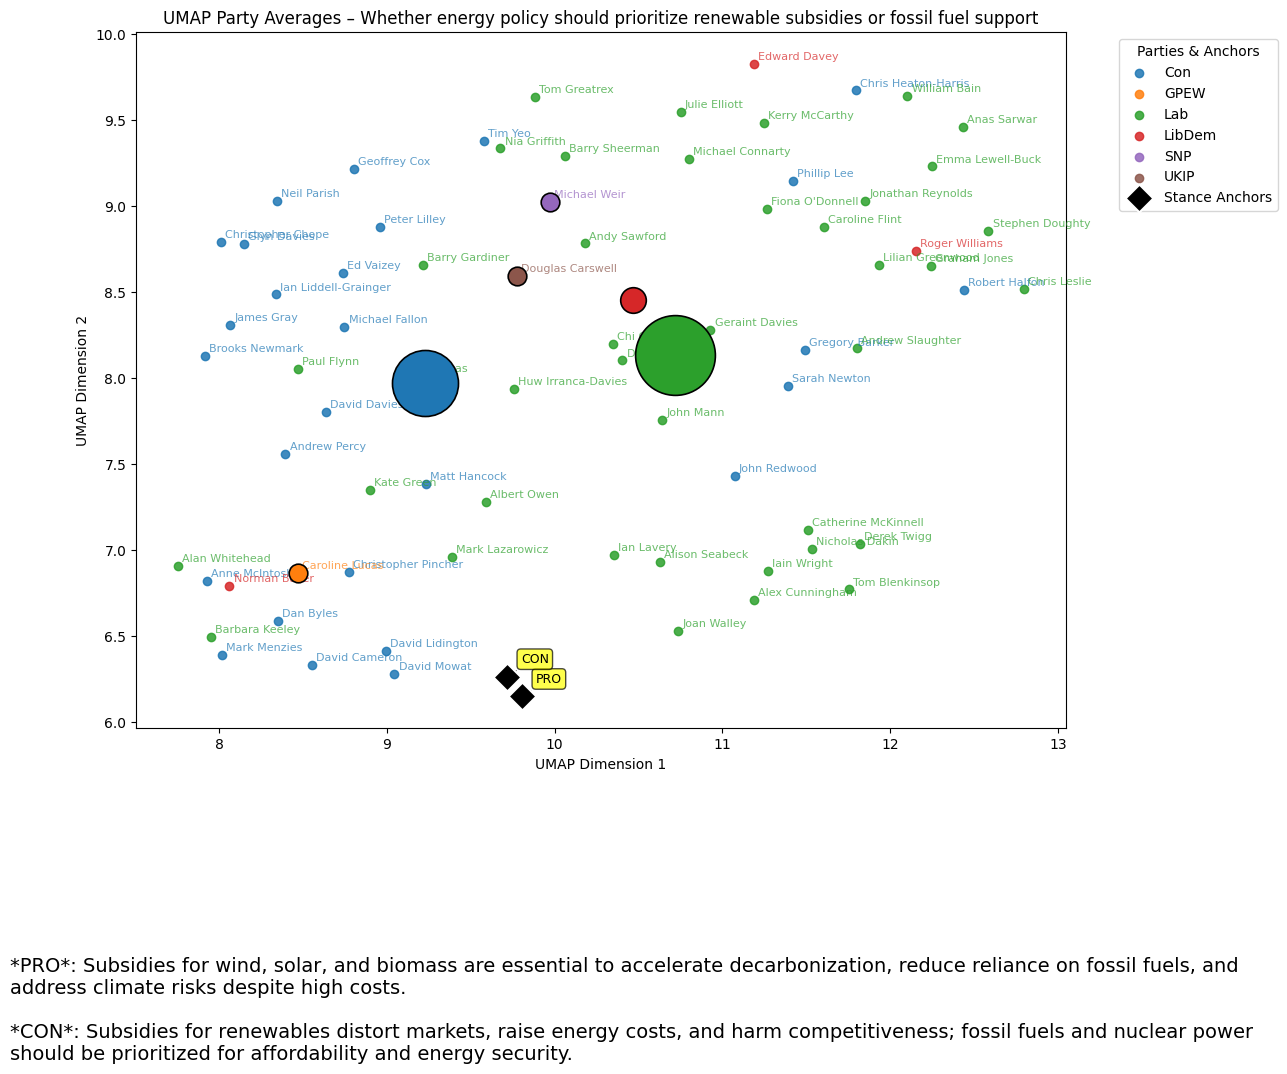

In [43]:
speaker_embeddings, anchor_embeddings, top_politicians = uk.compute_embeddings(topic, chosen_anchor, model_name=embedding_model)
umap_data = uk.compute_umap_embeddings(
    topic,
    chosen_anchor,
    speaker_embeddings=speaker_embeddings,
    anchor_embeddings=anchor_embeddings,
 )
save_path=f'./../data/processed/plot_umap/{topic}_{summarization_model}_{anchor_number}_'
uk.plot_umap_party_averages(umap_data, save_path=save_path)

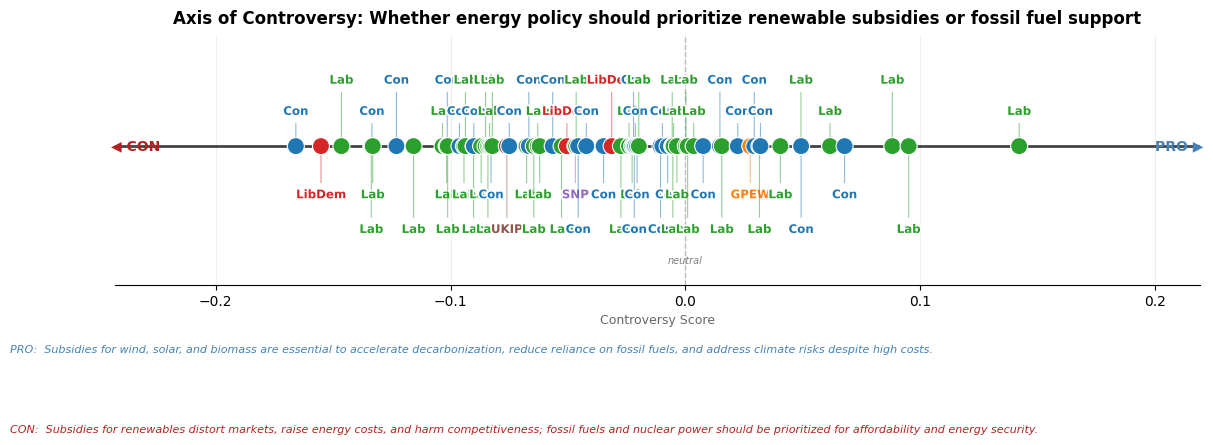

In [44]:
issue = chosen_anchor['topic']
speaker_df = uk.axis_of_controversy(topic, issue=issue, speaker_embeddings=speaker_embeddings, anchor_embeddings=anchor_embeddings)
speaker_df = speaker_df.sort_values(by='controversy_score', ascending=True)
# plot axis of controversy with speakers projected onto it
uk.plot_axis_of_controversy(speaker_df, issue=issue, anchors=chosen_anchor)

### Validation with external LLM

In [46]:
party_order = (
            speaker_df.groupby('party')['controversy_score']
            .mean()
            .sort_values()
            .index.tolist()
        )
party_order

['LibDem', 'UKIP', 'SNP', 'Con', 'Lab', 'GPEW']

In [47]:
#------ INSERT HERE THE ORDERINGS GIVEN BY THE EXTERNAL LLM -----------
ext_model='GPT-5.4 Thinking'
gold_ordering =  ['UKIP', 'Con', 'Lab', 'SNP', 'LibDem', 'GPEW']

In [48]:
# evaluation of the ordering of parties along the controversy axis
#get unique party labels in the speaker_df

party_order = (
            speaker_df.groupby('party')['controversy_score']
            .mean()
            .sort_values()
            .index.tolist()
        )

print("Predicted ordering:", party_order)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=party_order, gold_ordering=gold_ordering)
print(metrics)

Predicted ordering: ['LibDem', 'UKIP', 'SNP', 'Con', 'Lab', 'GPEW']
Gold standard ordering: ['UKIP', 'Con', 'Lab', 'SNP', 'LibDem', 'GPEW']
{'spearman_rho': np.float64(0.2571), 'spearman_p': np.float64(0.6228), 'kendall_tau': np.float64(0.2), 'kendall_p': np.float64(0.7194), 'lcs_ratio': 0.6667, 'n_parties': 6}


In [49]:
add_result(
    df=results_df,
    anchor=chosen_anchor,
    topic=topic,
    predicted_ordering=party_order,
    gold_ordering=gold_ordering,
    summarization_model=summarization_model,
    embedding_model=embedding_model,
    external_model=ext_model,
    kendall_tau=metrics['kendall_tau'],
    spearman_rho=metrics['spearman_rho'],
    kendall_p=metrics['kendall_p'],
    spearman_p=metrics['spearman_p'],
    lcs_ratio=metrics['lcs_ratio']
)
results_df.tail(1)

,anchor,topic,predicted_ordering,gold_ordering,summarization_model,embedding_model,external_model,kendall_tau,spearman_rho,kendall_p,lcs_ratio,spearman_p
9,{'topic': 'Whether energy policy should priori...,climate change,"[LibDem, UKIP, SNP, Con, Lab, GPEW]","[UKIP, Con, Lab, SNP, LibDem, GPEW]",qwen3:8b,Qwen/Qwen3-Embedding-0.6B,GPT-5.4 Thinking,0.2,0.2571,0.7194,0.6667,0.6228


In [50]:
results_df.to_csv('./../data/processed/evaluation_results.csv', index=False)